<a href="https://colab.research.google.com/github/MudasirH-coder/DeveloperHub-Corporation-1/blob/main/Customer_Bank_churn_prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Bank_Churn.csv')

In [ ]:
df.head(5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [ ]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Stats Summary
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
#filters a pandas DataFrame to retain only numeric columns and then computes their pairwise correlation matrix.
df.select_dtypes(include=np.number).corr()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [ ]:
#counts the frequency of unique values in a dataset
df.value_counts()

,,,,,,,,,,,,,count
CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,
15815316,Kennedy,644,France,Male,50,9,76817.00,4,1,0,196371.13,1,1
15815295,John,662,France,Female,38,2,96479.81,1,1,0,120259.41,0,1
15815271,Ritchie,755,Germany,Male,43,6,165048.50,3,1,0,16929.41,1,1
15815259,Fang,835,France,Female,56,2,0.00,2,1,1,39820.13,0,1
15815236,Chiganu,574,Spain,Male,34,5,0.00,2,0,0,28269.86,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15565796,Docherty,745,Germany,Male,48,10,96048.55,1,1,0,74510.65,0,1
15565779,Kent,627,Germany,Female,30,6,57809.32,1,1,0,188258.49,0,1
15565714,Cattaneo,601,France,Male,47,1,64430.06,2,0,1,96517.97,0,1


** Data Visualization**

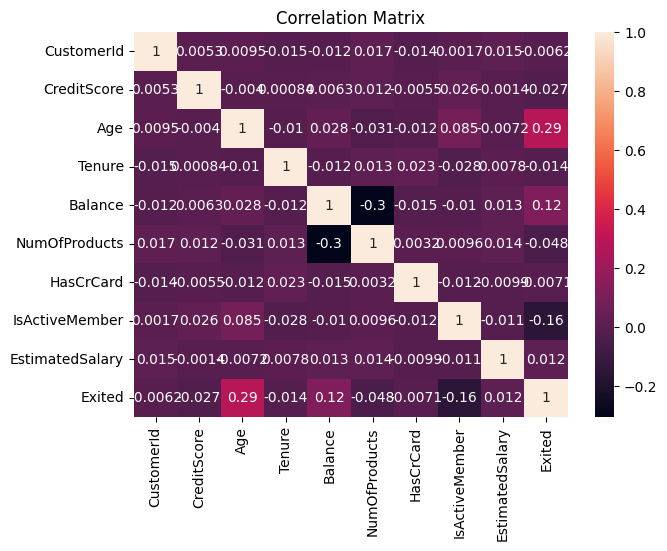

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Matrix')
plt.show()

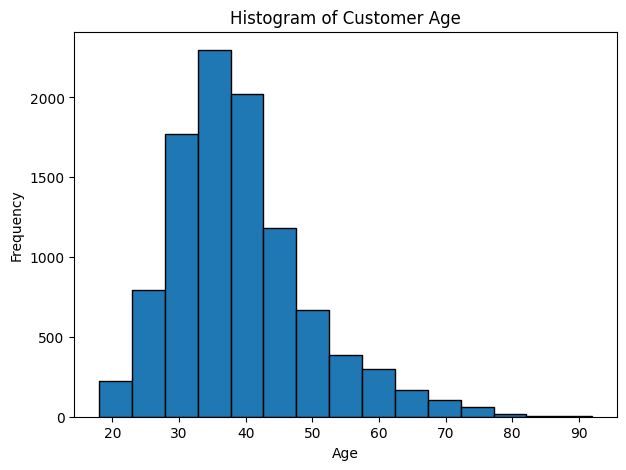

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(df['Age'], bins=15, edgecolor='black')

# Add labels and title
plt.title('Histogram of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Show plot
plt.show()

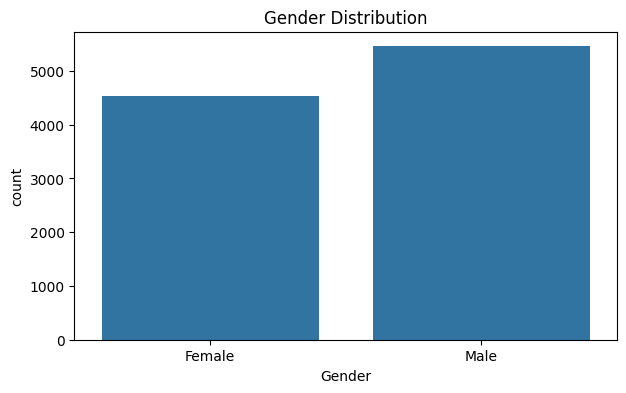

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='Gender',data=df)
plt.title('Gender Distribution')
plt.show()

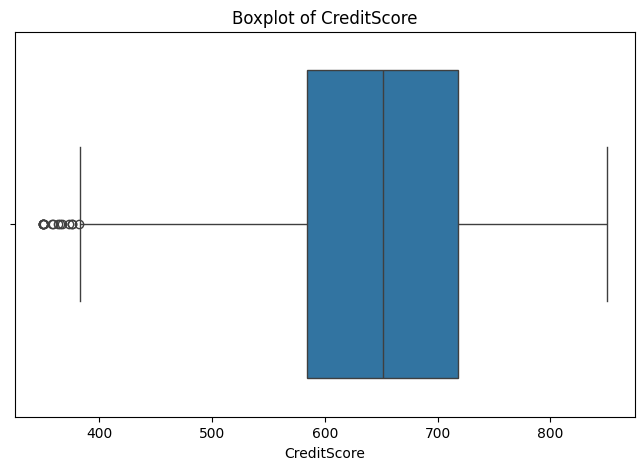

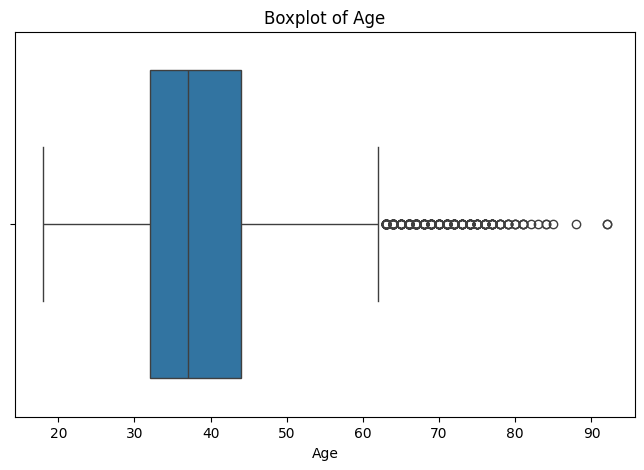

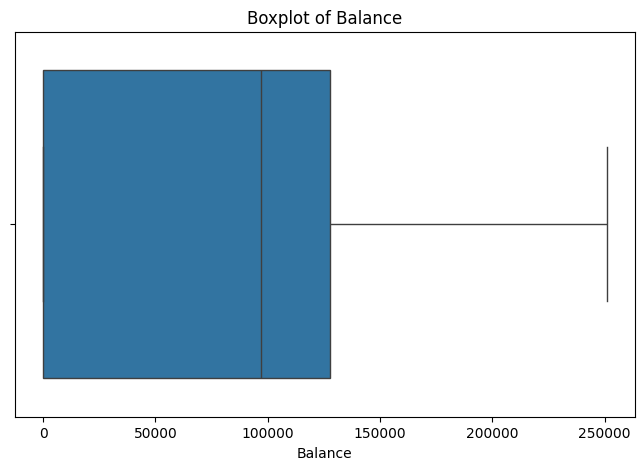

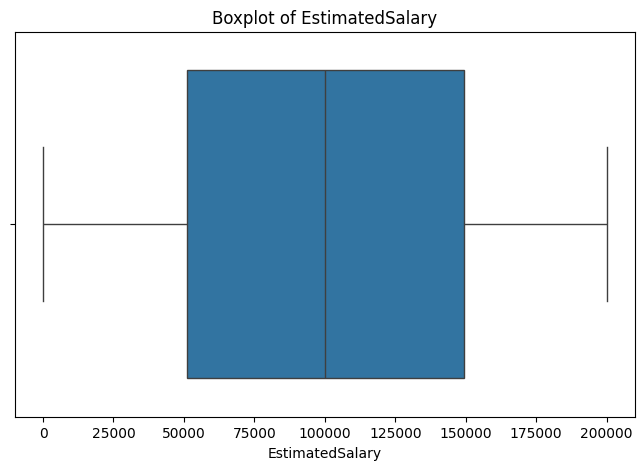

In [ ]:
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# Create boxplots
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

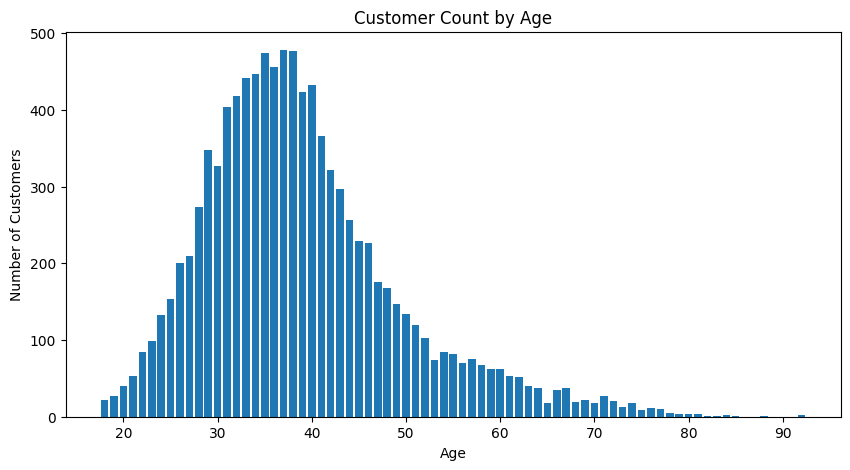

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Bank_Churn.csv')
age_counts = df['Age'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(age_counts.index, age_counts.values)

plt.title('Customer Count by Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

**Let's train the model **

In [8]:
#import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [9]:
df = pd.read_csv('/content/Bank_Churn.csv')

In [10]:
df.head(5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Check Data **

In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [14]:
print(df.isnull().sum())

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [15]:
#drop unnessary columns
df = df.drop(['CustomerId', 'Surname'], axis=1)

In [16]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [18]:
# Separate features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
#Train the Model

# Encode categorical features in X_train and X_test
# This step is necessary because the model requires numerical input.

# Apply Label Encoding for 'Gender'
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
X_train['Gender'] = le_gender.fit_transform(X_train['Gender'])
X_test['Gender'] = le_gender.transform(X_test['Gender'])

# Apply One-Hot Encoding for 'Geography'
# Create copies to avoid SettingWithCopyWarning
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

X_train_processed = pd.get_dummies(X_train_processed, columns=['Geography'], prefix='Geography', drop_first=True)
X_test_processed = pd.get_dummies(X_test_processed, columns=['Geography'], prefix='Geography', drop_first=True)

# Align columns - crucial step after separate one-hot encoding
# Get missing columns in test set that are in training set
missing_cols_in_test = set(X_train_processed.columns) - set(X_test_processed.columns)
for c in missing_cols_in_test:
    X_test_processed[c] = 0

# Get missing columns in training set that are in test set
missing_cols_in_train = set(X_test_processed.columns) - set(X_train_processed.columns)
for c in missing_cols_in_train:
    X_train_processed[c] = 0

# Ensure the order of columns is the same
X_test_processed = X_test_processed[X_train_processed.columns]

X_train = X_train_processed
X_test = X_test_processed


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
#Make Prediction
y_pred = model.predict(X_test)

In [22]:
#Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.866
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



**Predict for New Customer **

In [24]:
import pandas as pd

# The original features before any encoding, except for the dropped CustomerId and Surname
# These are the columns of X before train-test split
feature_columns_before_encoding = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
                     'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

# Create a DataFrame for the new customer with raw categorical values
# Assuming '1' for Geography was intended for 'Spain' and '0' for Gender for 'Female'
# It's crucial to use the original string values for categorical features here
new_customer_data = pd.DataFrame([
    {
        'CreditScore': 650,
        'Geography': 'Spain',   # Use the actual string value for Geography
        'Gender': 'Female',     # Use the actual string value for Gender
        'Age': 40,
        'Tenure': 5,
        'Balance': 50000,
        'NumOfProducts': 2,
        'HasCrCard': 1,
        'IsActiveMember': 1,
        'EstimatedSalary': 60000
    }
])

# Apply the same preprocessing steps as X_train
# 1. Label Encode 'Gender' using the fitted encoder from training
new_customer_data['Gender'] = le_gender.transform(new_customer_data['Gender'])

# 2. One-Hot Encode 'Geography' using the same approach as training
new_customer_processed = pd.get_dummies(new_customer_data, columns=['Geography'], prefix='Geography', drop_first=True)

# 3. Align columns with X_train_processed to ensure consistency with the trained model
# Get the expected column names from X_train_processed
expected_columns = X_train_processed.columns

# Add missing columns to new_customer_processed and set their values to 0
for col in expected_columns:
    if col not in new_customer_processed.columns:
        new_customer_processed[col] = 0


new_customer_processed = new_customer_processed[expected_columns]

prediction = model.predict(new_customer_processed)

if prediction[0] == 1:
    print("Customer will churn.")
else:
    print("Customer will stay.")

Customer will stay.
